<a href="https://colab.research.google.com/github/Harpreetstudent/Advanced-Topic-Assignment/blob/main/Advanced_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import Liberies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
# 2. upload Dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/MyDrive/austin_weather.csv'

Mounted at /content/drive


In [ ]:
# 3. Load Dataset into dataframe

print(df.head(365))
print(df.columns)


          Date  TempAvgF  Year  Month  DayOfYear
0   2013-12-21        60  2013     12        355
1   2013-12-22        48  2013     12        356
2   2013-12-23        45  2013     12        357
3   2013-12-24        46  2013     12        358
4   2013-12-25        50  2013     12        359
..         ...       ...   ...    ...        ...
360 2014-12-16        55  2014     12        350
361 2014-12-17        51  2014     12        351
362 2014-12-18        55  2014     12        352
363 2014-12-19        53  2014     12        353
364 2014-12-20        52  2014     12        354

[365 rows x 5 columns]
Index(['Date', 'TempAvgF', 'Year', 'Month', 'DayOfYear'], dtype='object')


In [ ]:
#4 Keep Required Columns, Date and TempAvgF
df = df[['Date', 'TempAvgF']].copy()

print("\nDataset after keeping only Date and TempAvgF:")
print(df.head(365))



Dataset after keeping only Date and TempAvgF:
           Date  TempAvgF
0    2013-12-21        60
1    2013-12-22        48
2    2013-12-23        45
3    2013-12-24        46
4    2013-12-25        50
..          ...       ...
360  2014-12-16        55
361  2014-12-17        51
362  2014-12-18        55
363  2014-12-19        53
364  2014-12-20        52

[365 rows x 2 columns]


In [ ]:
#  Check and clean missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df = df.dropna(subset=['Date', 'TempAvgF'])

print("\nMissing values after removing incomplete rows:")
print(df.isnull().sum())


Missing values before cleaning:
Date        0
TempAvgF    0
dtype: int64

Missing values after removing incomplete rows:
Date        0
TempAvgF    0
dtype: int64


In [ ]:
#5 Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove invalid dates if any
df = df.dropna(subset=['Date'])
print(df.head(365))

          Date  TempAvgF
0   2013-12-21        60
1   2013-12-22        48
2   2013-12-23        45
3   2013-12-24        46
4   2013-12-25        50
..         ...       ...
360 2014-12-16        55
361 2014-12-17        51
362 2014-12-18        55
363 2014-12-19        53
364 2014-12-20        52

[365 rows x 2 columns]


In [ ]:
#6 Convert Date column into Year, Month, DayOfYear columns
df['Year'] = df['Date'].dt.year.astype(int)
df['Month'] = df['Date'].dt.month.astype(int)
df['DayOfYear'] = df['Date'].dt.dayofyear.astype(int)

print("\nDataset after feature extraction:")
print(df.head(365))


Dataset after feature extraction:
          Date  TempAvgF  Year  Month  DayOfYear
0   2013-12-21        60  2013     12        355
1   2013-12-22        48  2013     12        356
2   2013-12-23        45  2013     12        357
3   2013-12-24        46  2013     12        358
4   2013-12-25        50  2013     12        359
..         ...       ...   ...    ...        ...
360 2014-12-16        55  2014     12        350
361 2014-12-17        51  2014     12        351
362 2014-12-18        55  2014     12        352
363 2014-12-19        53  2014     12        353
364 2014-12-20        52  2014     12        354

[365 rows x 5 columns]


In [ ]:
#7 Extract First year
first_year = df['Year'].min()
df_first_year = df[df['Year'] == 2014].copy()

# Sort by date just to keep correct daily order
df_first_year = df_first_year.sort_values('Date').reset_index(drop=True)

print(f"\nFirst year selected: {first_year}")
print(f"Number of rows in first year: {len(df_first_year)}")

print("\nPreview of first-year data:")
print(df_first_year.head(365))



First year selected: 2013
Number of rows in first year: 365

Preview of first-year data:
          Date  TempAvgF  Year  Month  DayOfYear
0   2014-01-01        54  2014      1          1
1   2014-01-02        44  2014      1          2
2   2014-01-03        43  2014      1          3
3   2014-01-04        57  2014      1          4
4   2014-01-05        47  2014      1          5
..         ...       ...   ...    ...        ...
360 2014-12-27        54  2014     12        361
361 2014-12-28        40  2014     12        362
362 2014-12-29        49  2014     12        363
363 2014-12-30        43  2014     12        364
364 2014-12-31        39  2014     12        365

[365 rows x 5 columns]


In [ ]:
#8 Create 25-day moving average
df_first_year['MovingAvg25'] = df_first_year['TempAvgF'].rolling(window=25).mean()


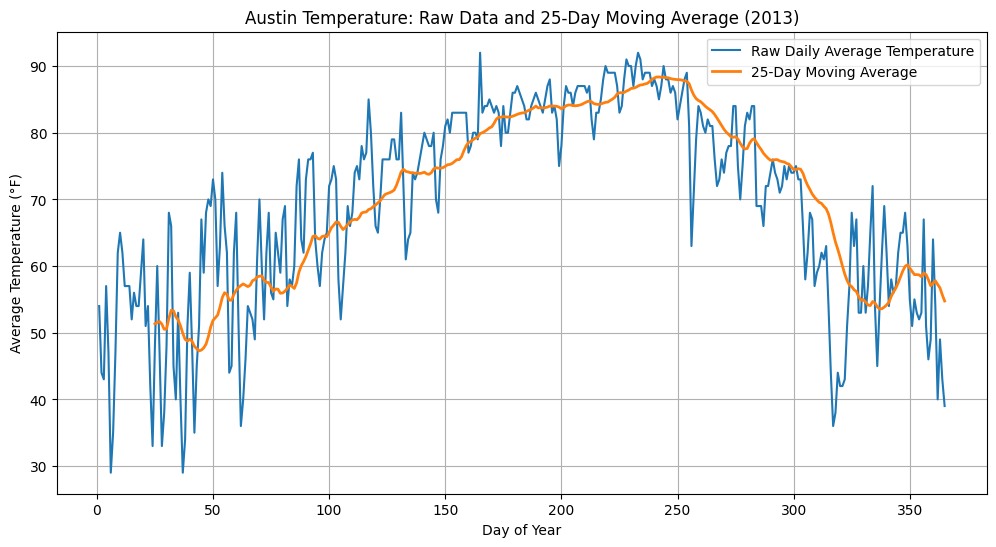

In [ ]:

#9 Plot raw data and moving average
df_first_year['MovingAvg25'] = df_first_year['TempAvgF'].rolling(window=25).mean()
plt.figure(figsize=(12, 6))
plt.plot(df_first_year['DayOfYear'], df_first_year['TempAvgF'], label='Raw Daily Average Temperature')
plt.plot(df_first_year['DayOfYear'], df_first_year['MovingAvg25'], label='25-Day Moving Average', linewidth=2)
plt.xlabel('Day of Year')
plt.ylabel('Average Temperature (°F)')
plt.title(f'Austin Temperature: Raw Data and 25-Day Moving Average ({first_year})')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


#10 Linear regression using least squares

# y = mx + c
# Input x = DayOfYear
# Output y = TempAvgF

x = df_first_year['DayOfYear'].values
y = df_first_year['TempAvgF'].values

slope, intercept = np.polyfit(x, y, 1)

print("\nLinear regression parameters:")
print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")


Linear regression parameters:
Slope (m): 0.02959234791707272
Intercept (c): 63.89966882432636


In [ ]:
#11 Calculate trendline values
df_first_year['Trendline'] = slope * df_first_year['DayOfYear'] + intercept

# first, middle, last

first_day = int(df_first_year['DayOfYear'].min())
middle_day = int(df_first_year['DayOfYear'].median())
last_day = int(df_first_year['DayOfYear'].max())

first_value = slope * first_day + intercept
middle_value = slope * middle_day + intercept
last_value = slope * last_day + intercept

print("\nTrendline values:")
print(f"Day {first_day}: {first_value:.2f}")
print(f"Day {middle_day}: {middle_value:.2f}")
print(f"Day {last_day}: {last_value:.2f}")



Trendline values:
Day 1: 63.93
Day 183: 69.32
Day 365: 74.70


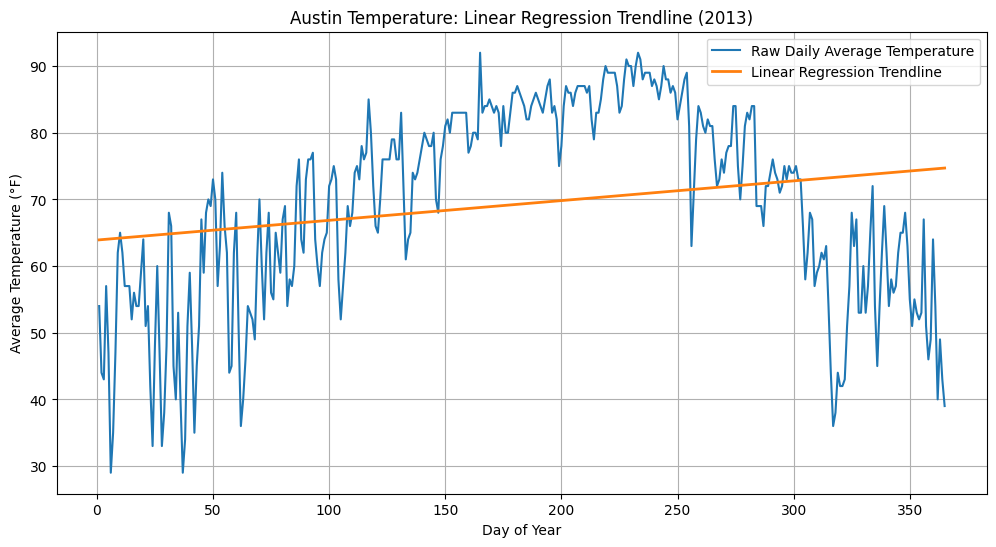

In [ ]:
#12 Plot raw data and trendline
df_first_year['Trendline'] = slope * df_first_year['DayOfYear'] + intercept
plt.figure(figsize=(12, 6))
plt.plot(df_first_year['DayOfYear'], df_first_year['TempAvgF'], label='Raw Daily Average Temperature')
plt.plot(df_first_year['DayOfYear'], df_first_year['Trendline'], label='Linear Regression Trendline', linewidth=2)
plt.xlabel('Day of Year')
plt.ylabel('Average Temperature (°F)')
plt.title(f'Austin Temperature: Linear Regression Trendline ({first_year})')
plt.legend()
plt.grid(True)
plt.show()

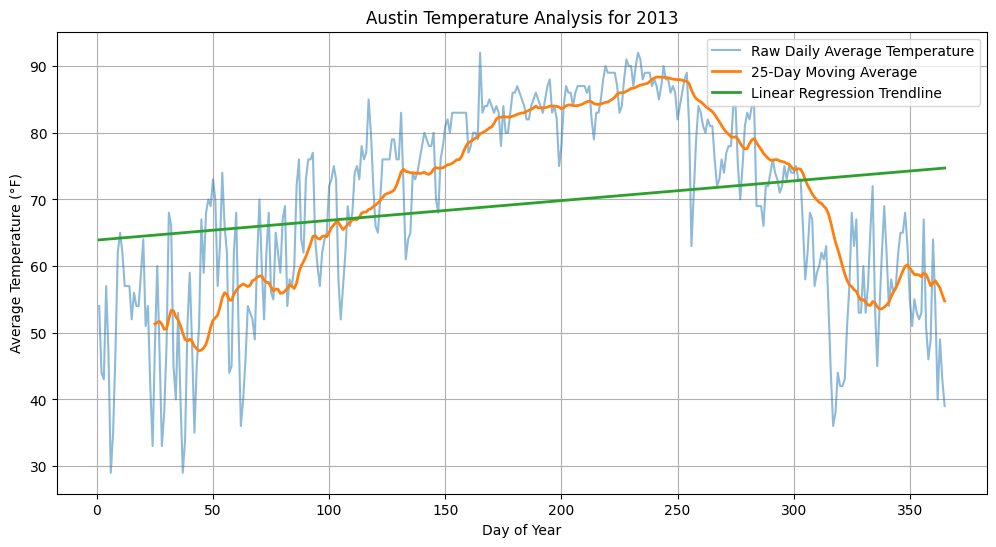

In [ ]:
#13 Combined plot
plt.figure(figsize=(12, 6))
plt.plot(df_first_year['DayOfYear'], df_first_year['TempAvgF'], alpha=0.5, label='Raw Daily Average Temperature')
plt.plot(df_first_year['DayOfYear'], df_first_year['MovingAvg25'], linewidth=2, label='25-Day Moving Average')
plt.plot(df_first_year['DayOfYear'], df_first_year['Trendline'], linewidth=2, label='Linear Regression Trendline')
plt.xlabel('Day of Year')
plt.ylabel('Average Temperature (°F)')
plt.title(f'Austin Temperature Analysis for {first_year}')
plt.legend()
plt.grid(True)
plt.show()


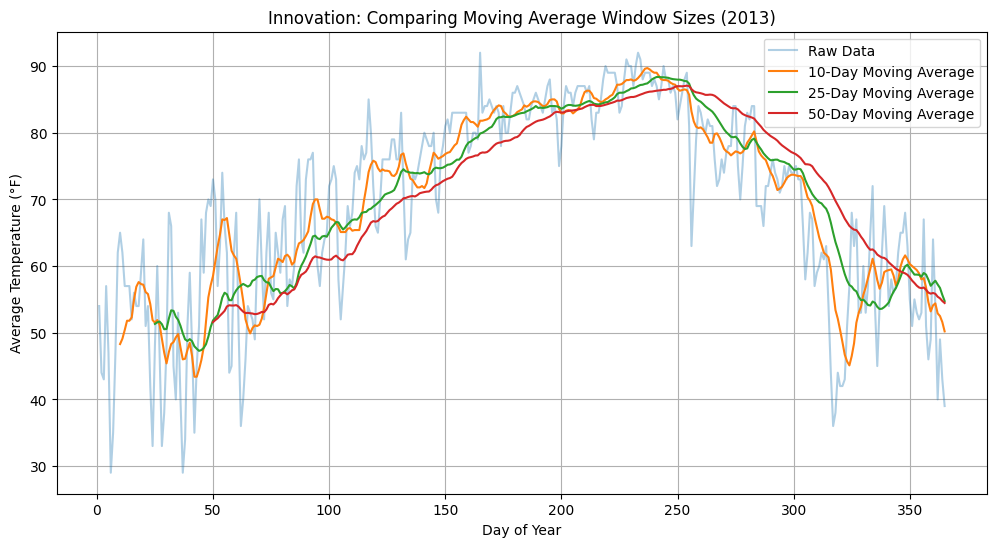

In [ ]:
# Compare different moving-average windows

df_first_year['MovingAvg10'] = df_first_year['TempAvgF'].rolling(window=10).mean()
df_first_year['MovingAvg50'] = df_first_year['TempAvgF'].rolling(window=50).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_first_year['DayOfYear'], df_first_year['TempAvgF'], alpha=0.35, label='Raw Data')
plt.plot(df_first_year['DayOfYear'], df_first_year['MovingAvg10'], label='10-Day Moving Average')
plt.plot(df_first_year['DayOfYear'], df_first_year['MovingAvg25'], label='25-Day Moving Average')
plt.plot(df_first_year['DayOfYear'], df_first_year['MovingAvg50'], label='50-Day Moving Average')
plt.xlabel('Day of Year')
plt.ylabel('Average Temperature (°F)')
plt.title(f'Innovation: Comparing Moving Average Window Sizes ({first_year})')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# descriptive statistics

print("\nDescriptive statistics for first-year temperature data:")
print(df_first_year['TempAvgF'].describe())



Descriptive statistics for first-year temperature data:
count    365.000000
mean      69.315068
std       14.801504
min       29.000000
25%       58.000000
50%       72.000000
75%       83.000000
max       92.000000
Name: TempAvgF, dtype: float64


To list the contents of a directory, you can use the `os.listdir()` function. This is useful for verifying if your file is in the expected location.

In [ ]:
len(df)


1319